In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad
import os

In [2]:
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
print(os.getcwd())

from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    assign_words_to_bins,
    compute_significance
)

/u/sebono/conversational_dominance/information_exchange_labelling


/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /u/sebono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /u/sebono/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
model_id="gpt2-large"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



In [75]:
import pandas as pd
import re
import numpy as np

multisimo_df_with_annotations = pd.read_csv("/u/sebono/conversational_dominance/data/processed/multisimo/transcript_dominance.csv")
multisimo_df_with_annotations

,file_name,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,speaker_2_5,speaker_1_dom_score,speaker_2_dom_score,file_content,speaker_1,speaker_2
0,S02,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,2.0,3.4,<MOD>: Ok so thanks for coming today. we're go...,P006,P007
1,S03,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,2.0,3.4,<MOD> Ok hello we are going to play a quiz. <...,P008,P009
2,S04,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.6,"<MOD>: ok Hello, thank you for coming today, w...",P010,P011
3,S05,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,1.0,3.8,2.0,"<MOD>: Ok hi welcome, thank you for coming tod...",P012,P013
4,S07,4.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,5.0,3.0,3.4,3.4,"<MOD>: <MOD>: Ok. So welcome, thank you very m...",P016,P017
5,S08,4.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,2.0,2.4,2.8,<MOD>: So good evening <SPK2>: Good evening. <...,P018,P019
6,S09,4.0,3.0,3.0,5.0,3.0,4.0,3.0,3.0,5.0,3.0,3.6,3.6,<MOD>: Ok <SPK2>: Yeah so <MOD>: So I would li...,P020,P021
7,S10,3.0,2.0,3.0,4.0,2.0,3.0,2.0,2.0,4.0,2.0,2.8,2.6,<MOD>: Ok. So I would like us to play a quiz. ...,P022,P023
8,S11,5.0,2.0,3.0,3.0,5.0,2.0,1.0,2.0,1.0,1.0,3.6,1.4,"<SPK1>: <MOD>: Right. So, I would like us to p...",P024,P025
9,S13,3.0,1.0,2.0,4.0,2.0,2.0,1.0,2.0,1.0,1.0,2.4,1.4,"<SPK1>: yeah <MOD>: Well hello, thanks very mu...",P028,P029


In [164]:
from glob import glob
ppls = ["p1", "p2", "p3"]
DATASET=multisimo
MODEL=model_id

path = "/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/{DATASET}_{PPL}_{MODEL}"
for el in glob()


In [144]:
file_name="S22"
dialog = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==file_name]["file_content"][16]

In [146]:
import re 
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

In [147]:
all_data = pd.DataFrame({})
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/multisimo_{p_name}_{model_id}/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[file_name]

In [148]:
all_data.bfill(inplace=True)

filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

assert len(filtered_tokens_p3) == len(token_list)
assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

all_data = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

In [149]:
baselined_ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
baselined_ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

In [150]:
print("\n".join([tokenizer.decode(token, skip_special_tokens=True) for token in filtered_tokens_p1]))

 Ah it's fine. Hello guys. Thanks very much for being here today. 
 We're going to play a quiz. 
 I'm going to ask you three questions that were previously posed to a group of hundred people. You'll have to find the three most popular answers 
 and then you need to talk to each other, you need to collaborate in order to order these answers in terms of popularity. 
 Is it cl 
 ok. 
 ear? 
 Yeah. 
 Yeah. 
 Ready to start? 
 Yeah. 
 Yeah. 
 Yeah. 
 So the first question is name a public place 
 where you're likely to catch a cold or a flu bug. 
 Ok. 
 A cold or a flu bug? 
 I guess a hospital is the 
 That's correc 
 Yeah. 
 t. Very good. 
 obvious one. 
 A hospital 
 Somewhere else you gonna be 
 Public 
 around 
 place 
 sick people, around lots of people in and in close proximi 
 hmm 
 ty then. 
 Yeah. 
 
 Probably college, a lecture maybe? 
 yeah You're ve ry close in that th 
 Or close 
 is 
 Classroom? 
 Yeah. 
 Ye ah. 
 So it's 
 Oh with kids an and unhygienic 
 So it's 
 mhmm 
 A 

In [151]:
[(el, np.mean(baselined_ppls_p2_spk[el])) for el in baselined_ppls_p2_spk.keys()]

[('<MOD>', 2.7498690015616343),
 ('<SPK1>', 1.9949796384503096),
 ('<SPK2>', 2.0387584537216212)]

In [152]:
filtered_matches_p3[filtered_matches_p3 == 'SPK1']

'<MOD>'

In [153]:
rows, nested = compute_significance(baselined_ppls_p2_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df.head()

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<MOD>,<SPK1>,697,597,0.301433,2.691490e-26,8.074470e-26
1,KS,<MOD>,<SPK2>,697,579,0.269846,9.086016e-21,1.362902e-20
2,KS,<SPK1>,<SPK2>,597,579,0.060328,2.223559e-01,2.223559e-01
3,Mann-Whitney U,<MOD>,<SPK1>,697,597,288242.000000,5.342156e-33,1.602647e-32
4,Mann-Whitney U,<MOD>,<SPK2>,697,579,276944.500000,1.879567e-30,2.819351e-30


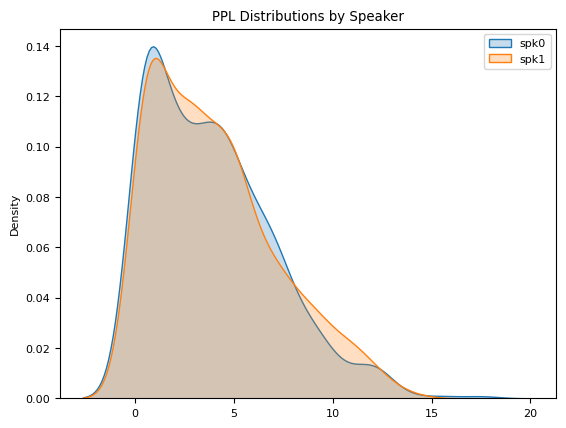

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p1_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(baselined_ppls_p1_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

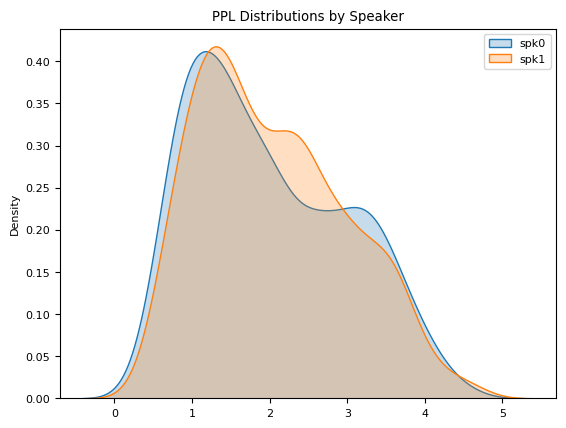

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p2_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(baselined_ppls_p2_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

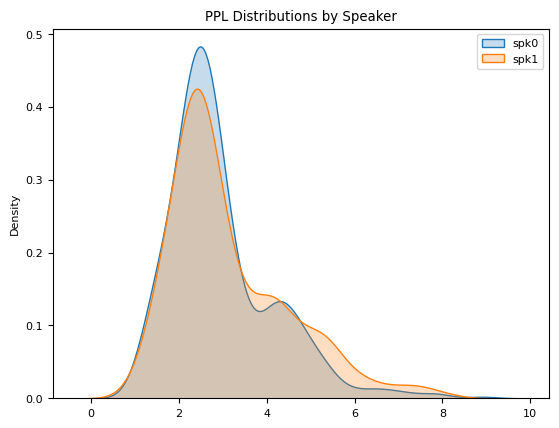

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p3_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(baselined_ppls_p3_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

### Plotting

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import plotly
import plotly.io as pio
pio.renderers.default = 'iframe'
import plotly.express as px
plotly.offline.init_notebook_mode(connected=True)
import seaborn as sns

cmp = 'algae'
def correlation_heatmap(y_cols, x_cols, full_data):
    '''
    Uses scipy.stats.spearmanr function
    Params:
    y_cols, x_cols: sets of column titles (strings)
    full_data: pandas dataframe that includes all columns listed in y_cols, x_cols
    Returns:
    corr: Spearman correlation coefficient matrix (y_cols = rows, x_cols = cols of matrix)
    fig_corr: annotated plotly heatmap of coefficients
    p: Spearman p-value matrix
    fig_p: annotated plotly heatmap of p-values
    '''
    cols = y_cols+x_cols
    all_correlations = scipy.stats.spearmanr(full_data[cols], nan_policy='omit')
    corr = all_correlations.statistic[:len(y_cols), -len(x_cols):]
    corr = pd.DataFrame(corr)
    corr.columns = x_cols
    corr.index = y_cols

    p = all_correlations.pvalue[:len(y_cols), -len(x_cols):]
    p = pd.DataFrame(p)
    p.columns = x_cols
    p.index = y_cols
    
    fig_corr = px.imshow(corr, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_r2 = px.imshow(corr**2, text_auto=True, aspect='auto', color_continuous_scale='agsunset')
    fig_p = px.imshow(p, text_auto=True, aspect='auto', color_continuous_scale='gray_r')

    return corr, fig_corr, p, fig_p, fig_r2

In [ ]:
# BEFORE
col_1 = ["p1","p2","p3"]
all_data = pd.read_csv("S02_multisimo_ppls_original.csv")
original_dialog_p1 = all_data["p1"]
original_dialog_p2 = all_data["p2"]
original_dialog_p3 = all_data["p3"]
#all_data = pd.DataFrame({"p1":original_dialog_p1, "p2": original_dialog_p2, "p3": original_dialog_p3})
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [ ]:
fig_corr

In [ ]:
all_data[["p1","p2","p3"]]

In [ ]:
# AFTER
col_1 = ["p1","p2","p3"]
#all_data = pd.DataFrame({"p1":baselined_p1_scores, "p2": baselined_p2_scores, "p3": baselined_p3_scores})
all_data = pd.read_csv("S02_multisimo_ppls_baselined.csv")
baselined_p1_scores = np.abs(all_data["p1"])
baselined_p2_scores = np.abs(all_data["p2"])
baselined_p3_scores = np.abs(all_data["p3"])
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [ ]:
fig_corr

In [ ]:
from utils import compute_graph_perplexity

In [ ]:
dialog_lines = full_dialog.replace("[","\n[").split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

In [ ]:
assert len(baselined_p1_scores) == encodings.input_ids.size(1)